In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load real Kaggle dataset
df = pd.read_csv('/content/bank.csv', sep=';')

print("✅ Data Loaded Successfully!")
print(f"Total Customers: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print()
print("Columns:", list(df.columns))
print()
df.head()


✅ Data Loaded Successfully!
Total Customers: 11162
Total Columns: 1

Columns: ['age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit']



,"age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit"
0,"59,admin.,married,secondary,no,2343,yes,no,unk..."
1,"56,admin.,married,secondary,no,45,no,no,unknow..."
2,"41,technician,married,secondary,no,1270,yes,no..."
3,"55,services,married,secondary,no,2476,yes,no,u..."
4,"54,admin.,married,tertiary,no,184,no,no,unknow..."


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fix: comma separator
df = pd.read_csv('/content/bank.csv', sep=',')

print("✅ Data Loaded!")
print("Shape:", df.shape)
print("Columns:", list(df.columns))

✅ Data Loaded!
Shape: (11162, 17)
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [7]:
print("=== DATASET OVERVIEW ===")
print()
print("Shape:", df.shape)
print()
print("Missing Values:")
print(df.isnull().sum())
print()
print("Response Distribution:")
print(df['deposit'].value_counts())
print()
response_rate = (df['deposit'] == 'yes').sum() / len(df) * 100
print(f"Overall Response Rate: {response_rate:.1f}%")

=== DATASET OVERVIEW ===

Shape: (11162, 17)

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Response Distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64

Overall Response Rate: 47.4%


/tmp/ipykernel_5818/389551709.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([df[df['deposit']=='yes']['balance'],


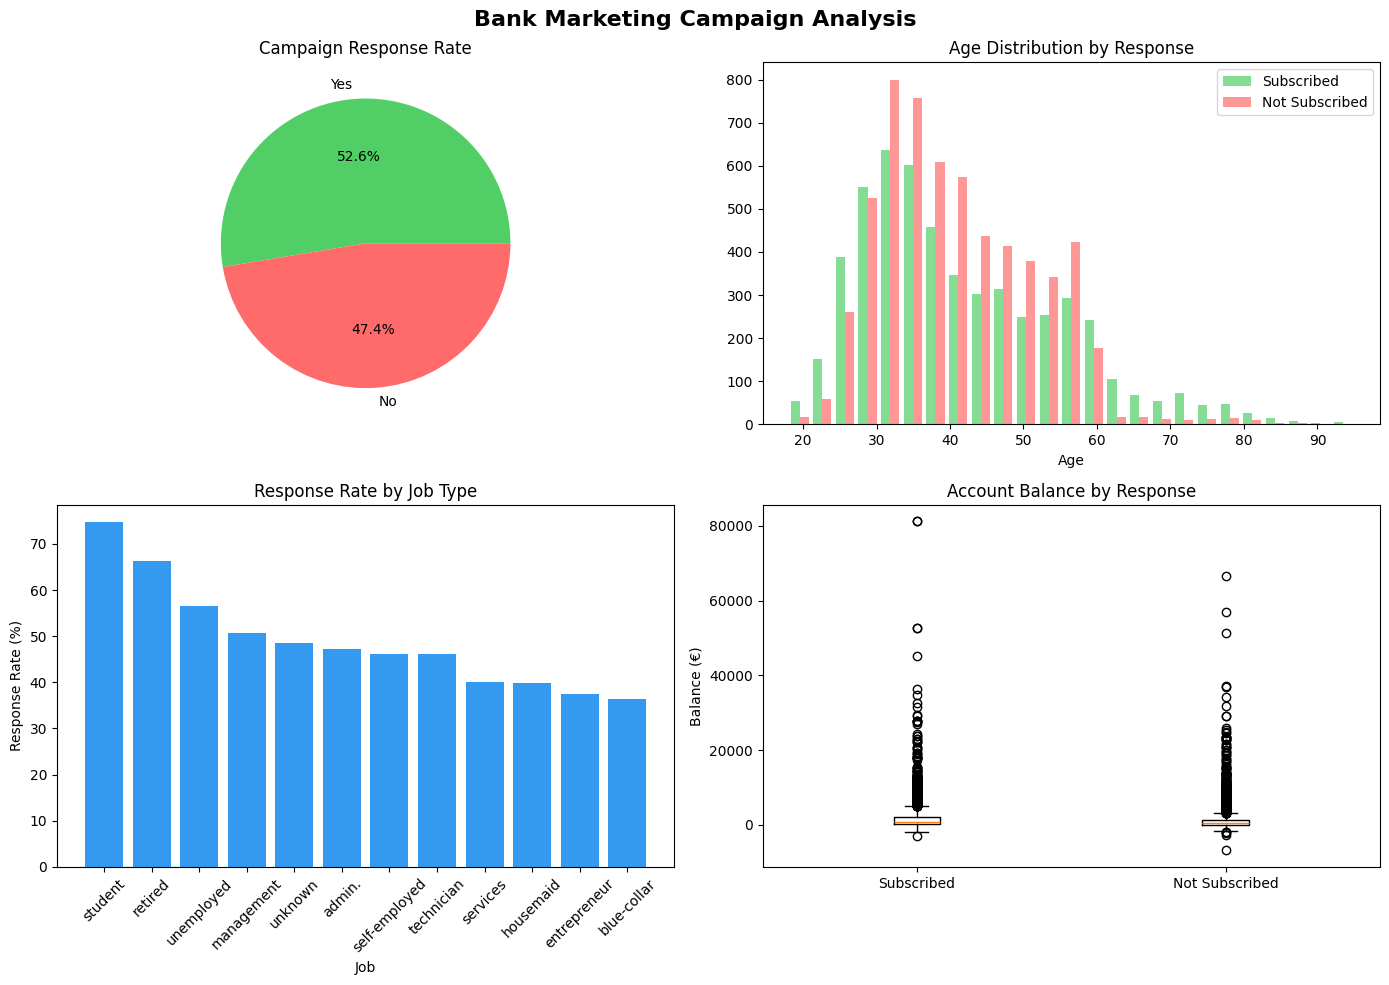

✅ Graphs saved!


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bank Marketing Campaign Analysis', fontsize=16, fontweight='bold')

# Graph 1 - Response Rate Pie Chart
response_counts = df['deposit'].value_counts()
axes[0,0].pie(response_counts, labels=['Yes', 'No'],
              autopct='%1.1f%%', colors=['#51cf66', '#ff6b6b'])
axes[0,0].set_title('Campaign Response Rate')

# Graph 2 - Age Distribution
df_yes = df[df['deposit'] == 'yes']['age']
df_no = df[df['deposit'] == 'no']['age']
axes[0,1].hist([df_yes, df_no], bins=25,
               label=['Subscribed', 'Not Subscribed'],
               color=['#51cf66', '#ff6b6b'], alpha=0.7)
axes[0,1].set_title('Age Distribution by Response')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# Graph 3 - Job vs Response Rate
job_response = df.groupby('job')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100).sort_values(ascending=False)
axes[1,0].bar(job_response.index, job_response.values, color='#339af0')
axes[1,0].set_title('Response Rate by Job Type')
axes[1,0].set_xlabel('Job')
axes[1,0].set_ylabel('Response Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# Graph 4 - Balance vs Response
axes[1,1].boxplot([df[df['deposit']=='yes']['balance'],
                   df[df['deposit']=='no']['balance']],
                   labels=['Subscribed', 'Not Subscribed'])
axes[1,1].set_title('Account Balance by Response')
axes[1,1].set_ylabel('Balance (€)')

plt.tight_layout()
plt.savefig('bank_campaign_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphs saved!")

In [10]:
print("=== KEY INSIGHTS FROM CAMPAIGN ANALYSIS ===")
print()

# Insight 1
response_rate = (df['deposit'] == 'yes').sum() / len(df) * 100
print(f"✅ Insight 1: Overall campaign response rate is {response_rate:.1f}%")

# Insight 2
avg_age_yes = df[df['deposit'] == 'yes']['age'].mean()
avg_age_no = df[df['deposit'] == 'no']['age'].mean()
print(f"✅ Insight 2: Subscribed customers avg age: {avg_age_yes:.1f}")
print(f"   Non-subscribed customers avg age: {avg_age_no:.1f}")

# Insight 3
best_job = df.groupby('job')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100).idxmax()
best_job_rate = df.groupby('job')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100).max()
print(f"✅ Insight 3: '{best_job}' job type has highest response rate: {best_job_rate:.1f}%")

# Insight 4
avg_bal_yes = df[df['deposit'] == 'yes']['balance'].mean()
avg_bal_no = df[df['deposit'] == 'no']['balance'].mean()
print(f"✅ Insight 4: Subscribed customers avg balance: €{avg_bal_yes:.0f}")
print(f"   Non-subscribed customers avg balance: €{avg_bal_no:.0f}")

# Insight 5
best_month = df[df['deposit'] == 'yes']['month'].value_counts().idxmax()
print(f"✅ Insight 5: Most successful campaign month: {best_month.upper()}")

print()
print("=== PROJECT 1 COMPLETE! ===")

=== KEY INSIGHTS FROM CAMPAIGN ANALYSIS ===

✅ Insight 1: Overall campaign response rate is 47.4%
✅ Insight 2: Subscribed customers avg age: 41.7
   Non-subscribed customers avg age: 40.8
✅ Insight 3: 'student' job type has highest response rate: 74.7%
✅ Insight 4: Subscribed customers avg balance: €1804
   Non-subscribed customers avg balance: €1280
✅ Insight 5: Most successful campaign month: MAY

=== PROJECT 1 COMPLETE! ===
